# Problema
Usted hace parte del equipo de análisis de información de una naviera y quiere conocer si existen
diferencias operacionales en los diferentes barcos utilizados para el transporte de mercancías con
el objetivo de mejorar el desempeño en las condiciones de trabajo de los empleados y de la
experiencia de los clientes de la naviera.
Conversando con los equipos técnicos se llega a una conclusión subjetiva que los barcos pueden
dividirse en dos grupos definidos. Utilizando estrategias de modelado, acepte o rechace esa
afirmación.

# Metodología ASUM-DM
## 1. Entendimiento del negocio
* Tenemos un caso en el que a partir de la información que tenemos de las navieras, hay que mirar si existen diferentes operaciones en el caso de la naviera, es decir, a partir de la información recopilada de los barcos hay que definir si estos realizan diferentes procesos para poder definir como trabajar para un mejor desempeño de los empleados y satisfaccion de los clientes.

* Se plantea con el equipo técnico que hay dos grupos definidos en las navieras (2 categorias marcadas). Nuestro objetivo principal es aceptar o rechazar esta propuesta

## 2. Enfoque analítico
* Elegimos una estrategia analítica: aprendizaje no supervisado mediante **clustering** (agrupamiento). No se parte de etiquetas o clases predefinidas, sino que se intenta descubrir patrones o grupos naturales entre los barcos con base en sus variables operacionales.

## 3. Requerimiento de datos
* La pregunta clave acá es: ¿Cuales son las variables que tengo o no que necesito?
* Necesitamos datos de la naviera, como lo son datos de los barcos, funcionamiento de estos, capacidad, ruta, velocidad, tipo de barco, entre otros

## 4. Recolección de datos
* En este caso, los datos han sido proporcionados por medio de un archivo csv con el nombre de "datos_caso_3", el cual contiene los datos separados por comas y hasta el momento es la única fuente necesaria para obtener los datos
* De este paso nos podemos devolver al paso 3 si es necesario
![image.png](attachment:image.png)

## 5. Entendimiento de los datos
* Aquí se realiza un análisis exploratorio para entender la estructura del dataset:
    * Identificar si hay datos nulos, atípicos o inconsistentes
    * Revisión de los tipos de variable que tenemos
    * Exploración multivariable de los datos
    * Identificación de la correlación y multicolinealidad
    * Análisis estadístico básico (media, mediana, moda)




In [ ]:
# Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
style.use('ggplot')
import seaborn as sb
import warnings
warnings.filterwarnings("ignore")

In [ ]:
data = pd.read_csv('datos_caso_3.csv')
data

,Date,Ship_Type,Route_Type,Engine_Type,Maintenance_Status,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Weather_Condition,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,Weekly_Voyage_Count,Average_Load_Percentage
0,2023-06-04,Container Ship,NaN,Heavy Fuel Oil (HFO),Critical,12.597558,2062.983982,1030.943616,14.132284,Moderate,1959.017882,483832.354540,292183.273104,25.867077,1.455179,1.415653,1,93.769249
1,2023-06-11,Fish Carrier,Short-haul,Steam Turbine,Good,10.387580,1796.057415,1060.486382,14.653083,Rough,162.394712,483388.000509,883765.787360,63.248196,0.290361,0.885648,6,93.895372
2,2023-06-18,Container Ship,Long-haul,Diesel,Fair,20.749747,1648.556685,658.874144,7.199261,Moderate,178.040917,448543.404044,394018.746904,49.418150,0.499595,1.405813,9,96.218244
3,2023-06-25,Bulk Carrier,Transoceanic,Steam Turbine,Fair,21.055102,915.261795,1126.822519,11.789063,Moderate,1737.385346,261349.605449,87551.375175,22.409110,0.702906,1.370704,1,66.193698
4,2023-07-02,Fish Carrier,Transoceanic,Diesel,Fair,13.742777,1089.721803,1445.281159,9.727833,Moderate,260.595103,287718.375160,676121.459632,64.158231,1.331343,0.583383,8,80.008581
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2731,2024-06-02,Tanker,Short-haul,Heavy Fuel Oil (HFO),Good,11.607997,2918.395972,239.990359,13.700906,Moderate,318.111891,237975.067292,731584.322921,47.152337,1.000265,1.284895,3,74.813114
2732,2024-06-09,Bulk Carrier,Short-haul,Heavy Fuel Oil (HFO),Good,13.852798,2161.282358,831.355653,14.612775,NaN,218.309002,21029.021721,374365.370930,64.325916,0.653474,0.891085,2,84.595155
2733,2024-06-16,Container Ship,Short-haul,Steam Turbine,Critical,16.813713,1343.608006,1376.460622,9.306518,NaN,1630.646419,78883.312529,234120.365052,53.551090,0.594169,0.725404,6,80.975269
2734,2024-06-23,Tanker,Transoceanic,Heavy Fuel Oil (HFO),Good,23.132643,2028.143572,619.236340,6.623856,Moderate,153.441965,25241.550250,799713.737211,14.335517,0.895670,0.902960,2,92.853622


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2736 entries, 0 to 2735
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     2736 non-null   object 
 1   Ship_Type                2600 non-null   object 
 2   Route_Type               2600 non-null   object 
 3   Engine_Type              2600 non-null   object 
 4   Maintenance_Status       2600 non-null   object 
 5   Speed_Over_Ground_knots  2736 non-null   float64
 6   Engine_Power_kW          2736 non-null   float64
 7   Distance_Traveled_nm     2736 non-null   float64
 8   Draft_meters             2736 non-null   float64
 9   Weather_Condition        2600 non-null   object 
 10  Cargo_Weight_tons        2736 non-null   float64
 11  Operational_Cost_USD     2736 non-null   float64
 12  Revenue_per_Voyage_USD   2736 non-null   float64
 13  Turnaround_Time_hours    2736 non-null   float64
 14  Efficiency_nm_per_kWh   

* Primero realizamos una limpieza de los datos NAN

In [ ]:
data.isnull().sum() #cuántos datos nulos hay por cada variable

Date                         0
Ship_Type                  136
Route_Type                 136
Engine_Type                136
Maintenance_Status         136
Speed_Over_Ground_knots      0
Engine_Power_kW              0
Distance_Traveled_nm         0
Draft_meters                 0
Weather_Condition          136
Cargo_Weight_tons            0
Operational_Cost_USD         0
Revenue_per_Voyage_USD       0
Turnaround_Time_hours        0
Efficiency_nm_per_kWh        0
Seasonal_Impact_Score        0
Weekly_Voyage_Count          0
Average_Load_Percentage      0
dtype: int64

* Observamos que en 5 categorias hay 136 datos nulos, podemos observarlos mejor graficamente

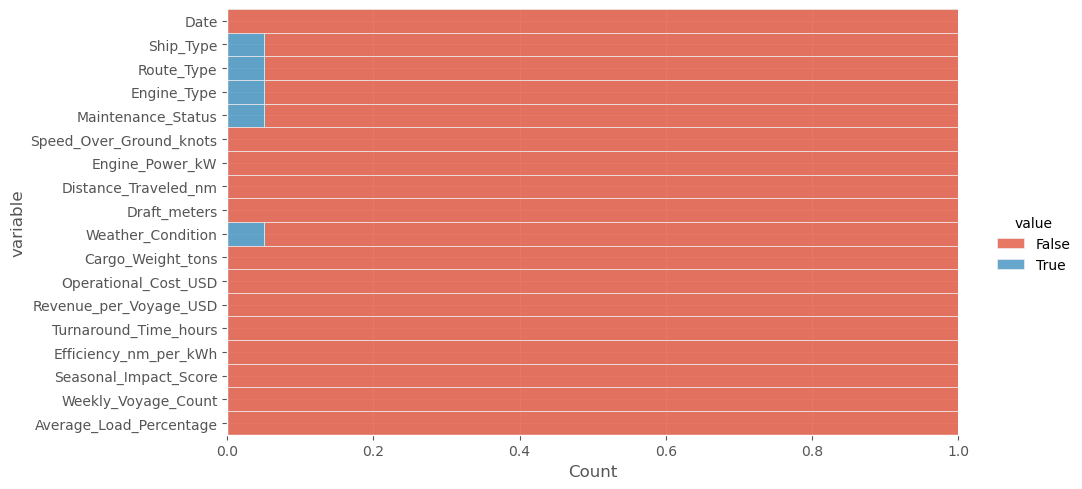

In [ ]:
data.isnull().melt().pipe(lambda df: sb.displot(data = df, y = 'variable', hue = 'value', multiple = 'fill', aspect = 2))
#isnull: True si hay dato nulo false si no hay datos nulos.
# melt: lista con todos los trues y false

* También podemos observar gráficamente las filas en las cuales hay por lo menos 1 dato NAN en una de sus columnas:

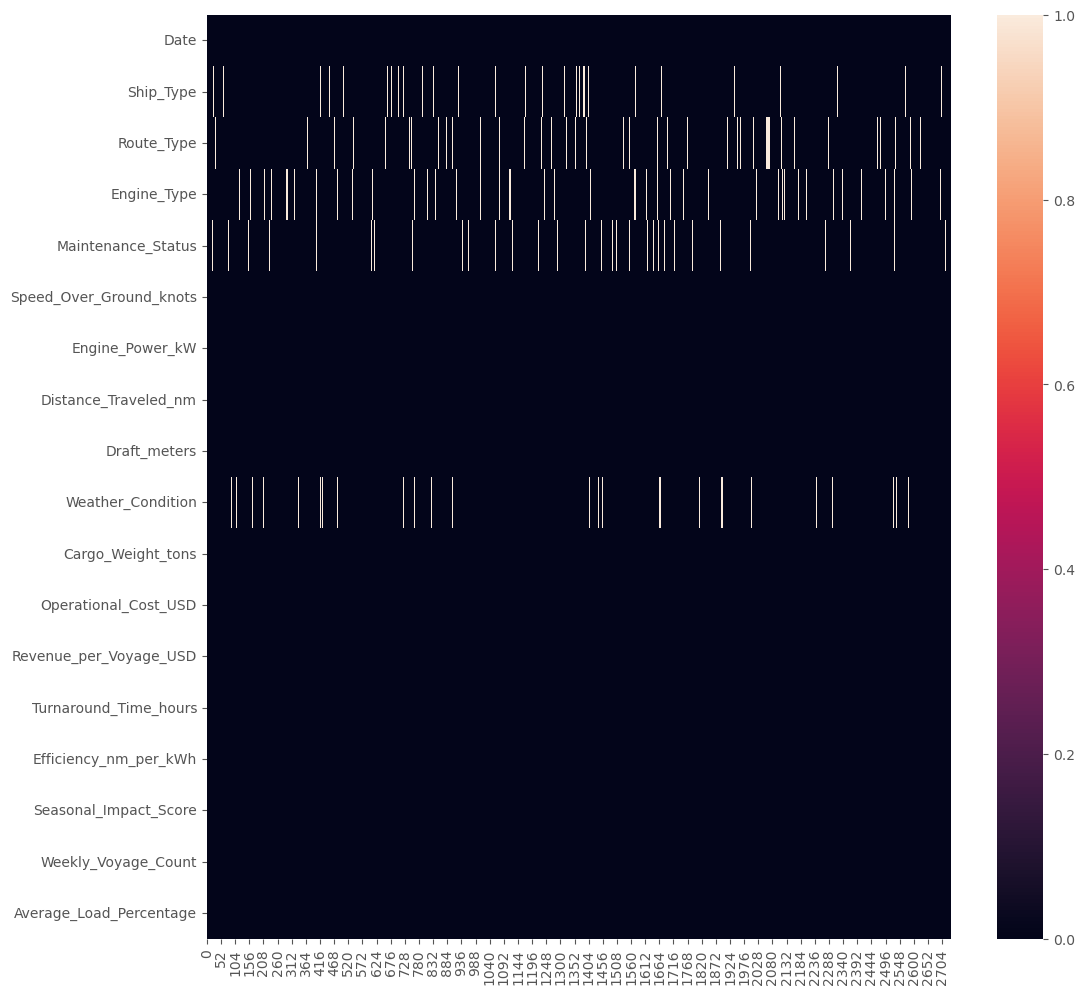

In [ ]:
plt.figure(figsize = (12,12))
data.isnull().transpose().pipe(lambda df: sb.heatmap(data = df))
plt.show()

* Podemos observar que los datos nulos representan menos del $5 \%$ en cada categoria, de las cuales solo 5 de las 18 categorias contienen datos nulos
* Por el momento, al no representar una gran cantidad de datos faltantes y por simplicidad, vamos a utilizar el .dropna() para eliminar las filas que contengan 1 dato NAN en alguna de sus columnas, quedándonos:

In [ ]:
data_clean = data.dropna()
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2127 entries, 1 to 2735
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     2127 non-null   object 
 1   Ship_Type                2127 non-null   object 
 2   Route_Type               2127 non-null   object 
 3   Engine_Type              2127 non-null   object 
 4   Maintenance_Status       2127 non-null   object 
 5   Speed_Over_Ground_knots  2127 non-null   float64
 6   Engine_Power_kW          2127 non-null   float64
 7   Distance_Traveled_nm     2127 non-null   float64
 8   Draft_meters             2127 non-null   float64
 9   Weather_Condition        2127 non-null   object 
 10  Cargo_Weight_tons        2127 non-null   float64
 11  Operational_Cost_USD     2127 non-null   float64
 12  Revenue_per_Voyage_USD   2127 non-null   float64
 13  Turnaround_Time_hours    2127 non-null   float64
 14  Efficiency_nm_per_kWh    2127

* Ahora realizamos una exploración univariada de los datos

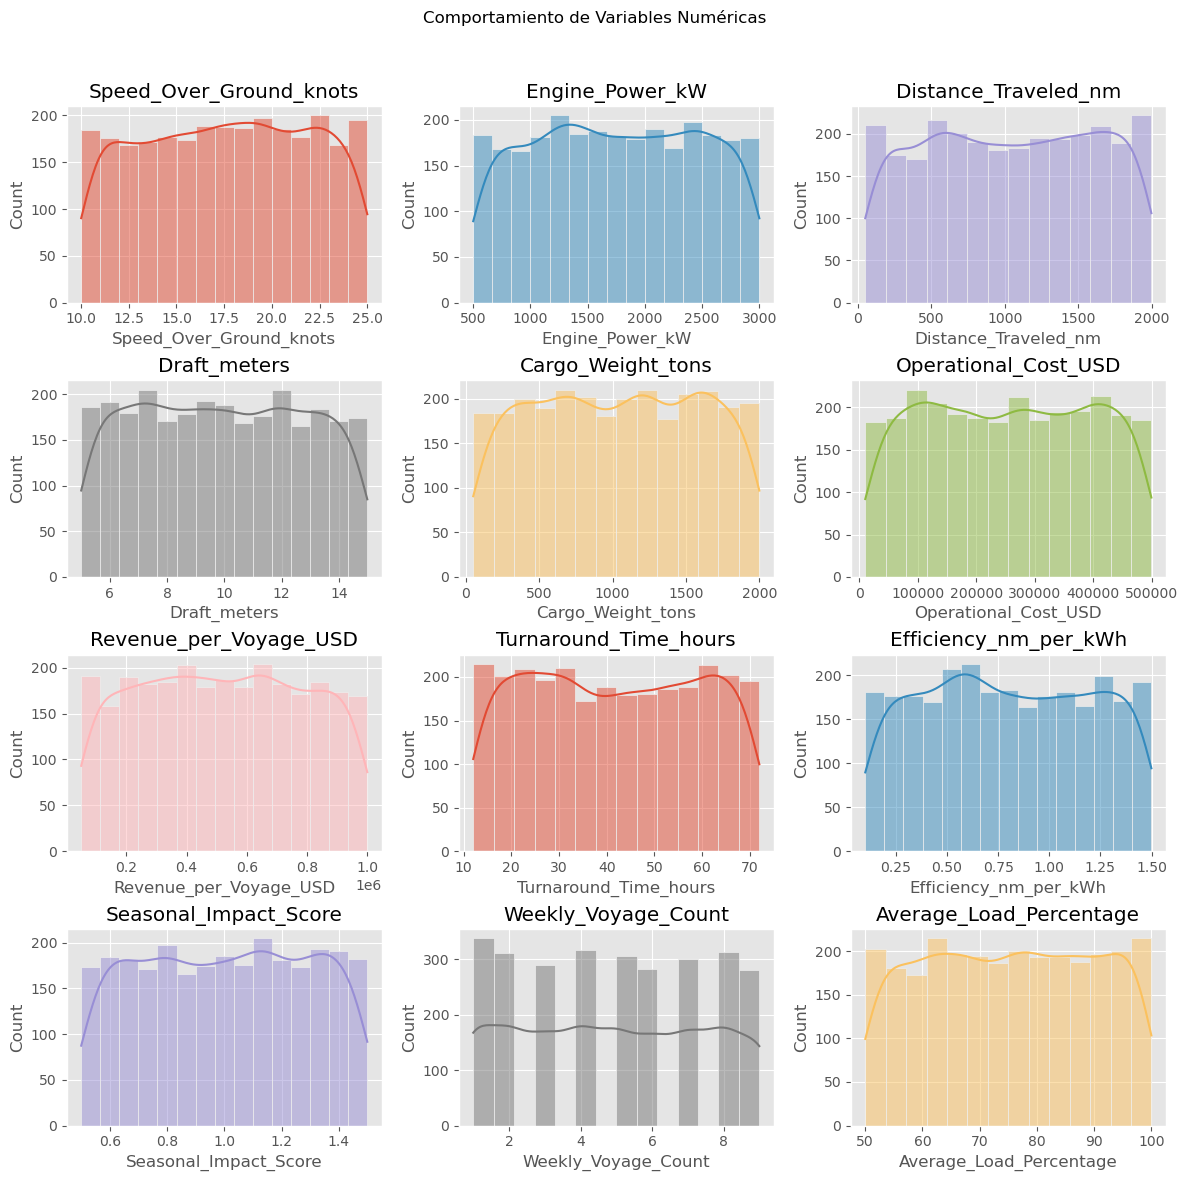

In [ ]:
## Para datos numéricos: histograma de frecuencia
## Para datos categóricos: gráficos de torta

### HISTOGRAMA DE FRECUENCIA
fig, ax = plt.subplots(4, 3, figsize = (12,12))
ax = ax.flat
num_col = data.select_dtypes(include = ['int64', 'float64']).columns

for i, col in enumerate(num_col):
    sb.histplot(data = data, x = col, kde = True,
                color = (list(plt.rcParams['axes.prop_cycle']) * 7)[i]['color'], ax = ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle('Comportamiento de Variables Numéricas')
plt.show()

* Podemos ver que:
    * Speed_Over_ground_knots, Average_Load_percentage, Engine_Power_kw, Draft_meters, Revenue_per_voyage_USB
        * Son casi uniformes pero tienen como una pequeña forma a ser bimodal (como con dos picos)
        * Draft Meters tiene un dato atípico a la derecha (bajo)
    
    * Distance_Traveled_nm, Turnaround_Time_hours
        * Tiene una forma marcada de bimodal (con dos picos)
    
    * Operational_Cost_USB, Seasonal_Impact_Score
        * Tiene una forma marcada de uniforme
        * Operational_Cost tiene un dato atípico a la derecha (alto)
    * Efficiency_nm_per_kwh
        * se nota como un sesgo marcado a la izquierda
    
    *  Weekly_voyage_count
        * parece tener valores discretos repetitivos (como 2, 4, 6, 8), lo que nos indica un claro patron en la Cantidad de viajes semanales
    * Cargo_weight_tons
        * Se nota dos datos bastante atípicos en el lado derecho
    


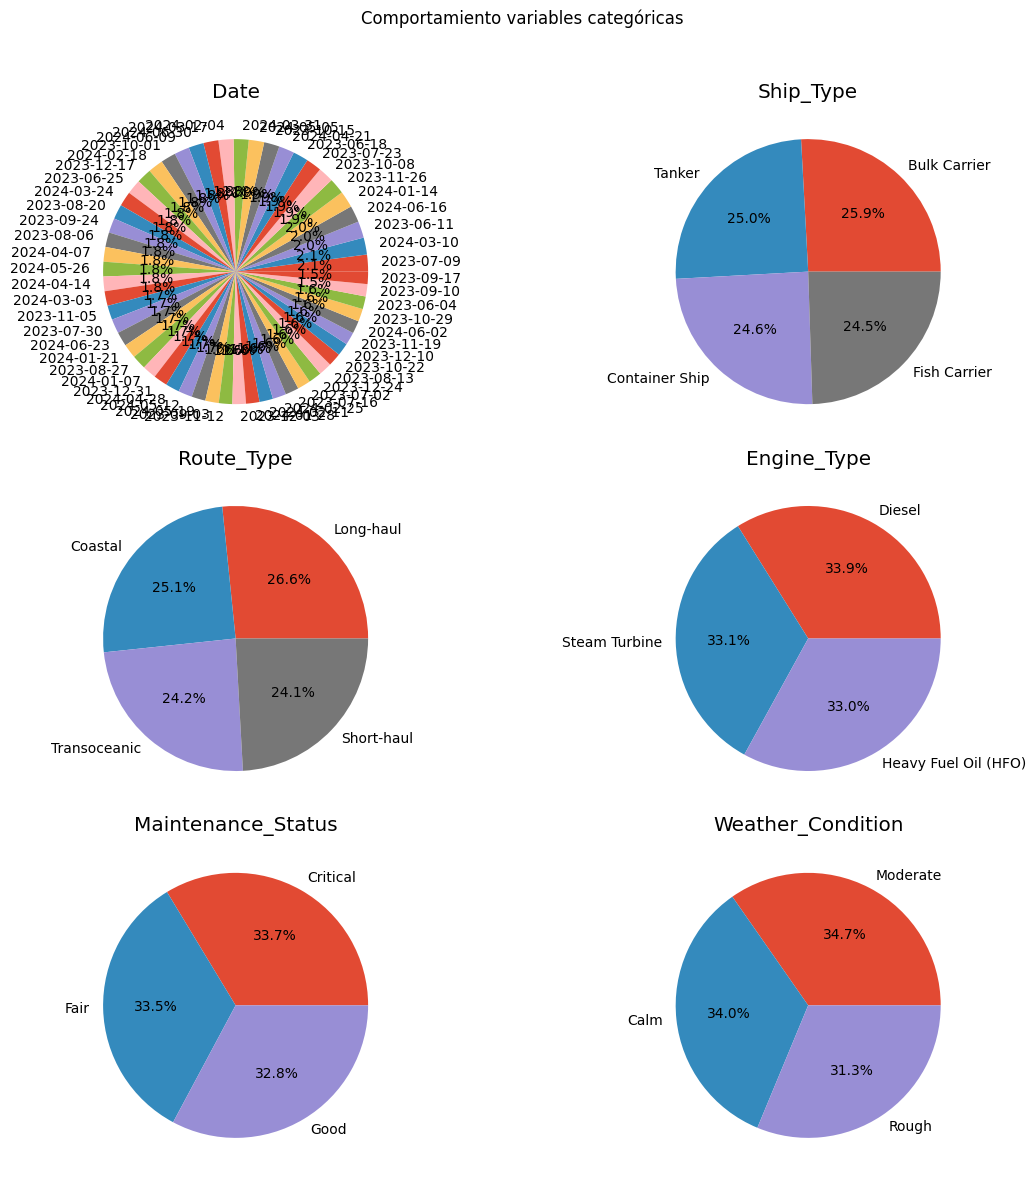

In [ ]:
##Gráficos de torta
fig, ax = plt.subplots(3, 2, figsize = (12,12))
ax = ax.flat
cat_col = data_clean.select_dtypes(include = ['object']).columns
#cat_col = cat_col.drop('Date') -> Elimina la torta de Date
for i, col in enumerate(cat_col):
    ax[i].pie(x = data_clean[col].value_counts(), labels = data_clean[col].value_counts().index, autopct = '%0.1f%%')
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle('Comportamiento variables categóricas')
plt.show()

* Se observa que las variables categóricas están todas muy bien balanceada, sin ninguna tener alguna tendencia
* La única que se puede ignorar seria Date

In [ ]:
clean_data = data_clean.drop(columns = ['Date'])
clean_data

,Ship_Type,Route_Type,Engine_Type,Maintenance_Status,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Weather_Condition,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,Weekly_Voyage_Count,Average_Load_Percentage
1,Fish Carrier,Short-haul,Steam Turbine,Good,10.387580,1796.057415,1060.486382,14.653083,Rough,162.394712,483388.000509,883765.787360,63.248196,0.290361,0.885648,6,93.895372
2,Container Ship,Long-haul,Diesel,Fair,20.749747,1648.556685,658.874144,7.199261,Moderate,178.040917,448543.404044,394018.746904,49.418150,0.499595,1.405813,9,96.218244
3,Bulk Carrier,Transoceanic,Steam Turbine,Fair,21.055102,915.261795,1126.822519,11.789063,Moderate,1737.385346,261349.605449,87551.375175,22.409110,0.702906,1.370704,1,66.193698
4,Fish Carrier,Transoceanic,Diesel,Fair,13.742777,1089.721803,1445.281159,9.727833,Moderate,260.595103,287718.375160,676121.459632,64.158231,1.331343,0.583383,8,80.008581
5,Fish Carrier,Long-haul,Heavy Fuel Oil (HFO),Fair,18.616196,2171.646567,723.304215,14.916320,Rough,1912.509751,184569.045384,776698.354849,47.476155,1.370206,1.437725,7,53.174898
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2729,Container Ship,Long-haul,Heavy Fuel Oil (HFO),Good,24.257402,1813.474360,147.964296,10.378736,Moderate,1450.181358,266359.224719,820652.038923,34.433655,0.708172,1.352973,7,51.258697
2730,Tanker,Long-haul,Diesel,Critical,15.649207,1662.426557,1175.942724,12.564046,Rough,451.670997,393827.995941,567287.169653,22.281638,0.356031,1.079178,2,92.926949
2731,Tanker,Short-haul,Heavy Fuel Oil (HFO),Good,11.607997,2918.395972,239.990359,13.700906,Moderate,318.111891,237975.067292,731584.322921,47.152337,1.000265,1.284895,3,74.813114
2734,Tanker,Transoceanic,Heavy Fuel Oil (HFO),Good,23.132643,2028.143572,619.236340,6.623856,Moderate,153.441965,25241.550250,799713.737211,14.335517,0.895670,0.902960,2,92.853622


* ahora analicemos correlación:

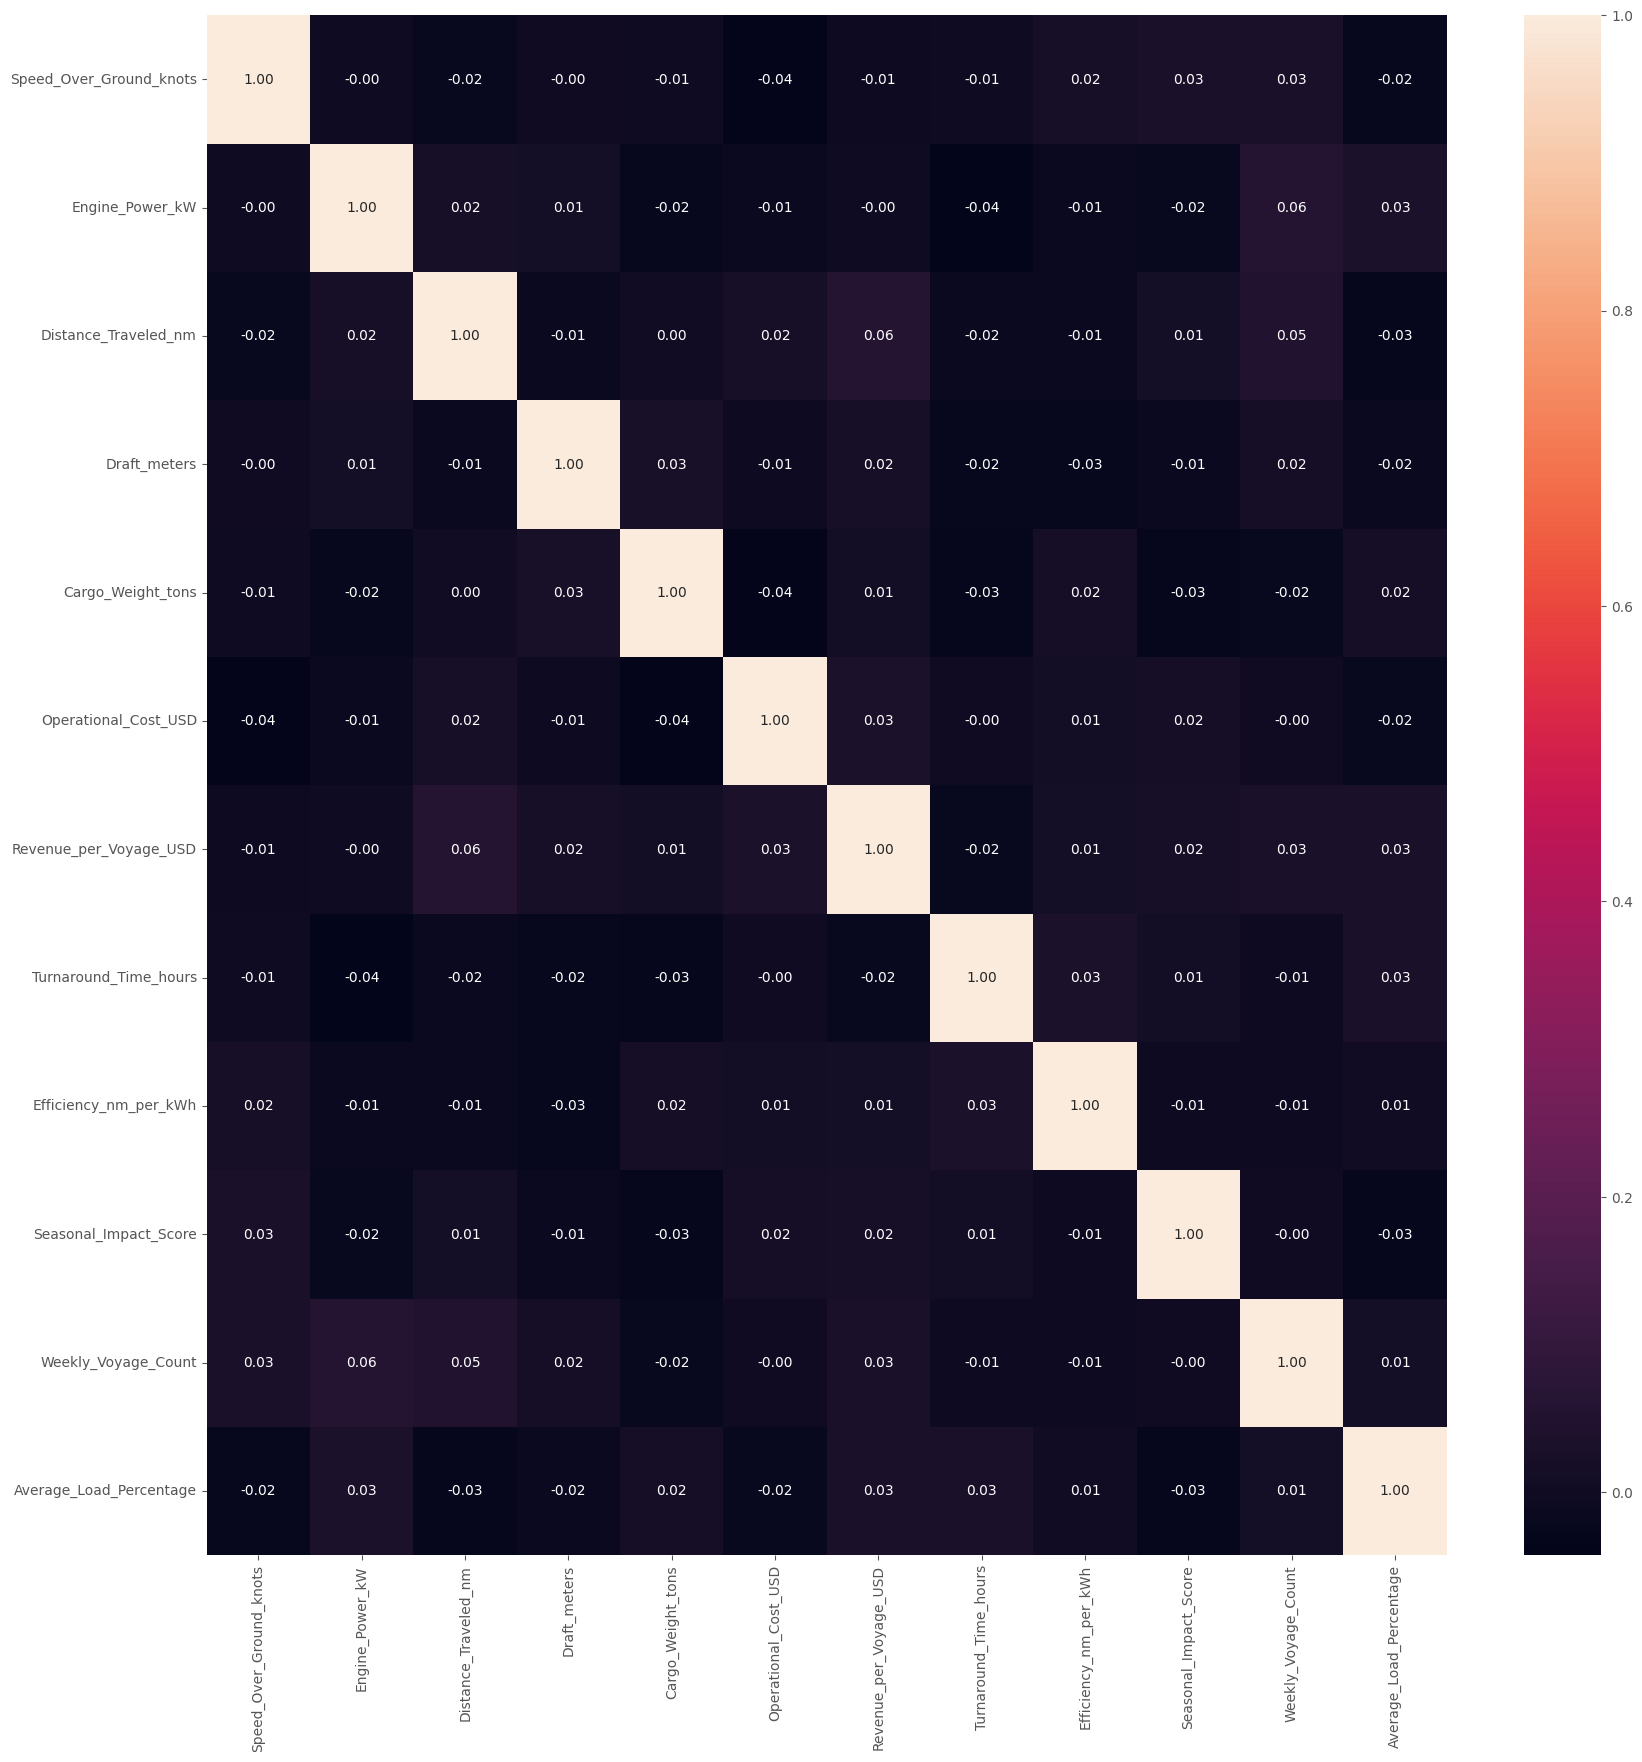

In [ ]:
#Gráfico de correlación para análisis multivariado
plt.figure(figsize = (20,20))
sb.heatmap(data = clean_data.corr(numeric_only= True), annot= True, fmt='.2f')
plt.show()

* Todas las variables tienen correlación nula, lo cual es muy común en datos reales que no suelen ser perfectos y por el momento no tenemos que eliminar variables redundantes

## 6. Preparación de los datos
* Se necesita una buena preparación de los datos para que todo funcione bien
* ¿Como dejo los datos listos para el modelo?
    - Se eliminan o imputan valores faltantes.
    - Se estandarizan las variables para que todas estén en la misma escala.
    - Se transforman variables categóricas si van a ser utilizadas.
    - Se eliminan variables irrelevantes o redundantes.


* Primero hacemos una transformacion de las varibales para que sean entendidadas por el modelo.

In [ ]:
#Transformación de variables
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline

In [ ]:
#Identificar las columnas según su tipo
num_col = clean_data.select_dtypes(include=['int64', 'float64']).columns.to_list()
cat_col = clean_data.select_dtypes(include=['object']).columns.to_list()

#Definir el tipo de transformación por tipo de dato
num_tranformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])
cat_transformer = Pipeline(steps=[('encoder', OneHotEncoder())])

#Diseño del transformador de columnas
preprocessor = ColumnTransformer(transformers=[
    ('num', num_tranformer, num_col),
    ('cat', cat_transformer, cat_col)
], remainder = 'passthrough')
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('scaler', MinMaxScaler())]),
                                 ['Speed_Over_Ground_knots', 'Engine_Power_kW',
                                  'Distance_Traveled_nm', 'Draft_meters',
                                  'Cargo_Weight_tons', 'Operational_Cost_USD',
                                  'Revenue_per_Voyage_USD',
                                  'Turnaround_Time_hours',
                                  'Efficiency_nm_per_kWh',
                                  'Seasonal_Impact_Score',
                                  'Weekly_Voyage_Count',
                                  'Average_Load_Percentage']),
                                ('cat',
                                 Pipeline(steps=[('encoder', OneHotEncoder())]),
                                 ['Ship_Type', 'Route_Type', 'Engine_Type',
                                  'Maintenance_Status', 'Weather_Condition'])])

In [ ]:
data_pre = preprocessor.fit_transform(clean_data)
data_pre

array([[0.0252187 , 0.51835035, 0.5185334 , ..., 0.        , 0.        ,
        1.        ],
       [0.71686414, 0.45927906, 0.31235678, ..., 0.        , 1.        ,
        0.        ],
       [0.73724575, 0.16560815, 0.55258854, ..., 0.        , 1.        ,
        0.        ],
       ...,
       [0.10667813, 0.96782599, 0.09731343, ..., 0.        , 1.        ,
        0.        ],
       [0.87591574, 0.61129652, 0.29200783, ..., 0.        , 1.        ,
        0.        ],
       [0.10133764, 0.97190775, 0.96503869, ..., 0.        , 1.        ,
        0.        ]])

In [ ]:
cod_cat = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_col)
labels =  np.concatenate([num_col, cod_cat])
data_pro = pd.DataFrame(data_pre, columns = labels)
data_pro.head()

,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,...,Route_Type_Transoceanic,Engine_Type_Diesel,Engine_Type_Heavy Fuel Oil (HFO),Engine_Type_Steam Turbine,Maintenance_Status_Critical,Maintenance_Status_Fair,Maintenance_Status_Good,Weather_Condition_Calm,Weather_Condition_Moderate,Weather_Condition_Rough
0,0.025219,0.518350,0.518533,0.966277,0.057553,0.966614,0.877777,0.854481,0.136018,0.385945,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.716864,0.459279,0.312357,0.219996,0.065581,0.895450,0.361960,0.623798,0.285686,0.906517,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.737246,0.165608,0.552589,0.679530,0.865698,0.513139,0.039180,0.173291,0.431118,0.871380,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0.249169,0.235476,0.716076,0.473158,0.107941,0.566993,0.659079,0.869660,0.880651,0.083444,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.574456,0.668767,0.345433,0.992633,0.955556,0.356328,0.765010,0.591406,0.908450,0.938453,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


## 7. Modelos de datos
### **Kmeans**

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

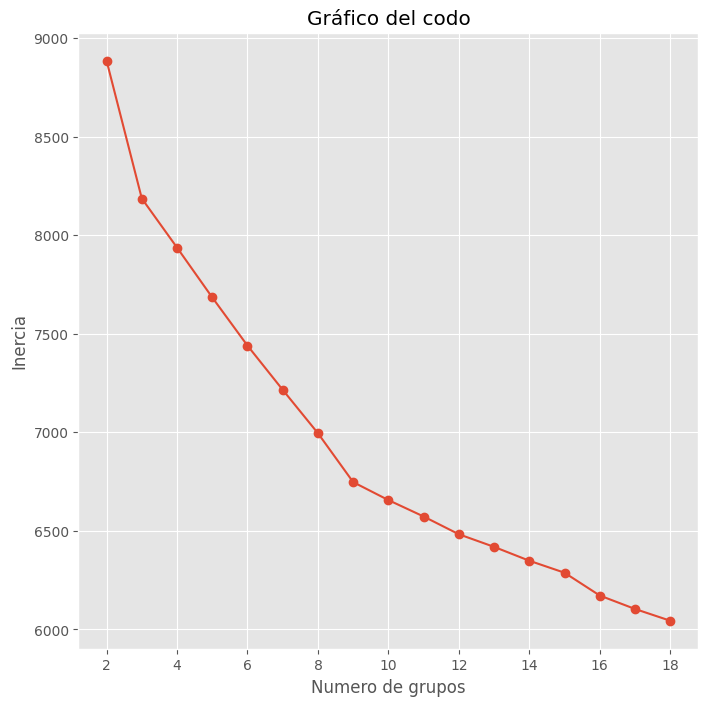

In [ ]:
# Buscar el valor de k
range_k = range(2,19)
inertia = []

for n_clusters in range_k:
    kmeans_model = KMeans(n_clusters = n_clusters, n_init= 20, random_state= 123)
    # random_state es com una semila
    # n_init = lo que hace es que acota el rango de distancia en la que se buscan los puntos, es para que sea mas rapido

    kmeans_model.fit(data_pro)
    inertia.append(kmeans_model.inertia_)

plt.figure(figsize=(8,8))
plt.plot(range_k, inertia, marker = "o")
plt.title("Gráfico del codo")
plt.xlabel("Numero de grupos")
plt.ylabel("Inercia")
plt.show()

* Podemos observar con la gráfica del codo, este está entre 8 y 9, por lo tanto el número ideal de $k$ serían entre 8 y 9 grupos, lo que nos dice que los grupos de las caracteristicas de los barcos serían mejor explicados con esta cantidad de grupos
* Ahora utilicemos la métrica de silhouette

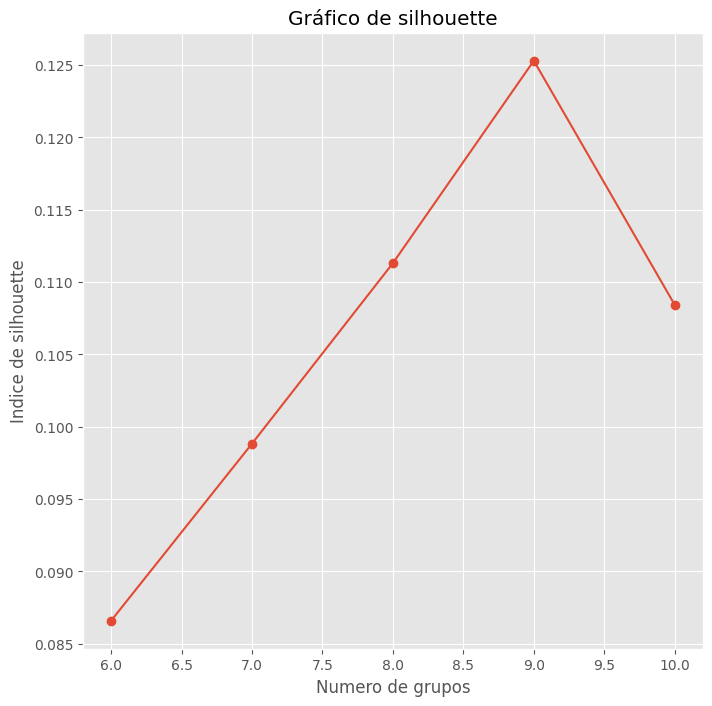

In [ ]:
# Busqueda fina de k
range_k= range (6,11)
sil_score = []
for n_clusters in range_k:
    kmeans_model = KMeans(n_clusters = n_clusters, n_init= 20, random_state= 123)

    kmeans_model.fit(data_pro)
    cluster_label = kmeans_model.fit_predict(data_pro)
    sil_avg = silhouette_score(data_pro, cluster_label)
    sil_score.append(sil_avg)


plt.figure(figsize=(8,8))
plt.plot(range_k, sil_score, marker = "o")
plt.title("Gráfico de silhouette")
plt.xlabel("Numero de grupos")
plt.ylabel("Indice de silhouette")
plt.show()

* Vemos que el mayor valor de silhouette se dá cuando hay $k=9$, lo que nos reafirma nuestra anterior conclusion del gráfico del codo, por lo que vemos que sería mejor tener 9 grupos

In [ ]:
kmeans_model_final = KMeans(n_clusters=9, n_init=20, random_state=123)
kmeans_model_final.fit(data_pro)

KMeans(n_clusters=9, n_init=20, random_state=123)

### **Agrupamiento jerarquico**

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram

In [ ]:
#Función para dibujar el dendrograma
def dibujarDendrograma(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([model.children_, model.distances_, counts]).astype(float)

    # Plot
    dendrogram(linkage_matrix, **kwargs)

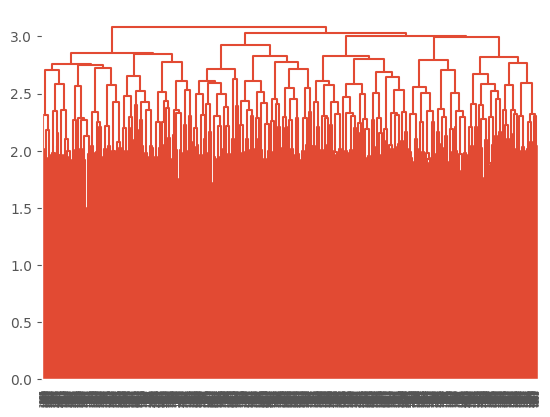

In [ ]:
# Promedio
h_clust_mean = AgglomerativeClustering(metric="euclidean", linkage= "average", distance_threshold=0, n_clusters= None)
h_clust_mean.fit(X = data_pro)
dibujarDendrograma(h_clust_mean, color_threshold = 0)

* Vemos que es mejor analizar el dendograma con la varianza. Del promedio no logramos ver casi nada por la cantidad de datos

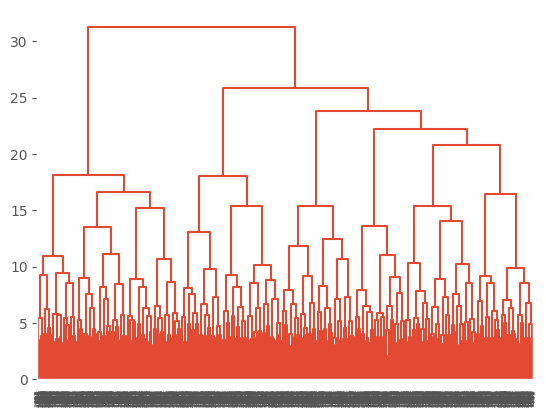

In [ ]:
# Varianza
h_clust_ward = AgglomerativeClustering(metric="euclidean", linkage= "ward", distance_threshold=0, n_clusters= None)
h_clust_ward.fit(X = data_pro)
dibujarDendrograma(h_clust_ward, color_threshold = 0)

* La distancia del dendograma que vamos a utilizar es la linea más larga del primer punto, que a ojimetro vemos que es aproximadamente 25

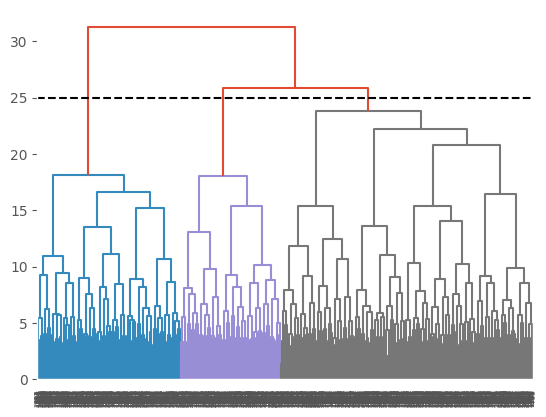

In [ ]:
dendrogram_pru = 25 # distancia a la que vamos a costar segund la linea mas larga del dendograma y su punto central
dibujarDendrograma(h_clust_ward, color_threshold = dendrogram_pru)
plt.axhline(y=dendrogram_pru, c = "black", linestyle = "--")
plt.show()

* Vemos que tiene 3 clusters

In [ ]:
h_clust_final = AgglomerativeClustering(metric="euclidean", linkage= "ward", n_clusters= 3) # 3 porque lo vemos de la grafica
h_clust_final.fit(data_pro)

AgglomerativeClustering(n_clusters=3)

### **DBSCAN**

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from itertools import product

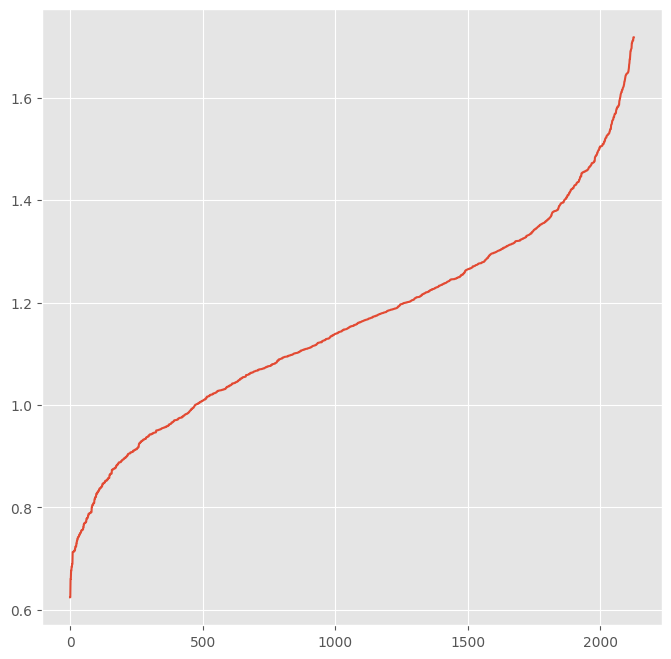

In [ ]:
neighbors = NearestNeighbors(n_neighbors= 3)
neighbors_fit = neighbors.fit(data_pro)
distance, index = neighbors_fit.kneighbors(data_pro)
distance = np.sort(distance, axis = 0)
distance = distance[:,1]
plt.figure(figsize=(8,8))
plt.plot(distance)
plt.show()

* Podemos observar que empieza a formarse una asíntota entre 1.4 y 1.6. Vamos a utilizar este rango de valores para el epsilon

In [ ]:
eps_values = np.arange(1.4, 1.6, 0.1)
min_samples = np.arange(2, 10)
dbscan_params = list(product(eps_values, min_samples))
sil_score = []
for p in dbscan_params:
    y_pred = DBSCAN(eps = p[0], min_samples = p[1]).fit_predict(data_pro)
    sil_score.append(silhouette_score(data_pro, y_pred))

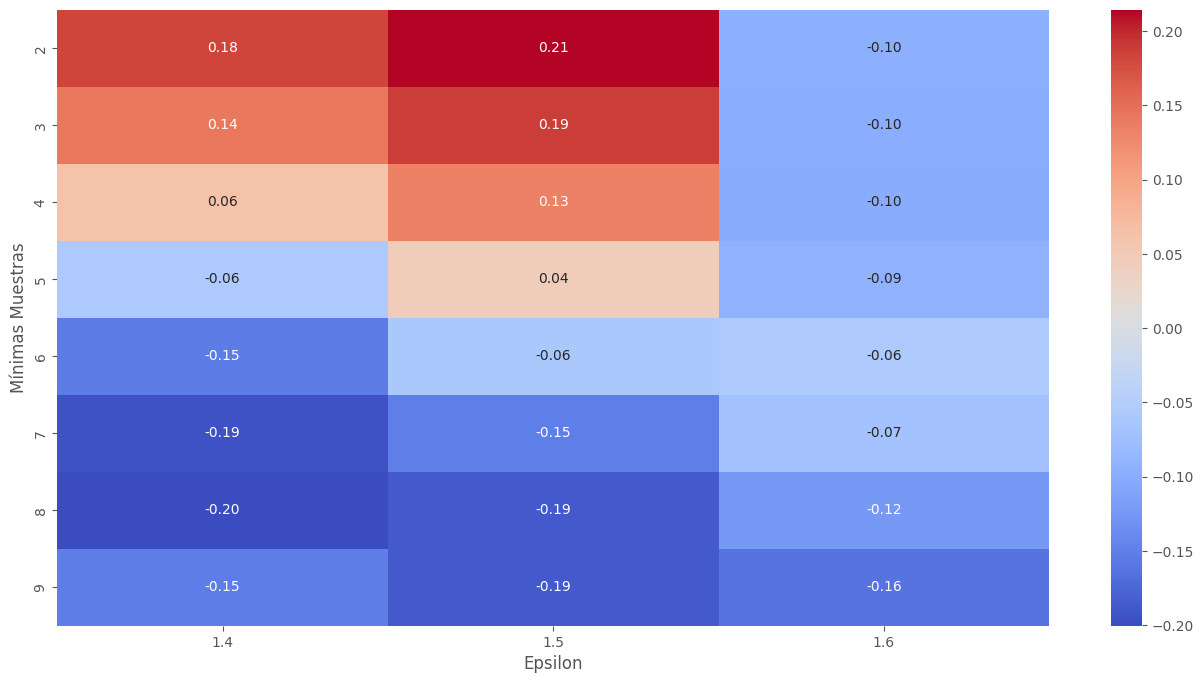

In [ ]:
df_param_adj = pd.DataFrame.from_records(dbscan_params, columns=["Epsilon", "Mínimas Muestras"])
df_param_adj["Score"] = sil_score
pivot_data = pd.pivot_table(df_param_adj,values="Score", index="Mínimas Muestras", columns="Epsilon")
plt.figure(figsize=(16,8))
sb.heatmap(pivot_data, annot= True, fmt = ".2f", cmap="coolwarm")
plt.show()

* Vemos que el mayor valor del indice de silhouette lo alcanza en 0.19 (no tomamos en cuenta cuando solo 2 muestras mínimas)
* Por lo que en este caso vamos a utilizar un epsilon de $1.5$ y minimas muestras de $3$

In [ ]:
dbscan_final = DBSCAN(eps = 1.5, min_samples=3) # min_sample = numero de vecinos
dbscan_final.fit(data_pro)

DBSCAN(eps=1.5, min_samples=3)

### **Gaussian mixture models (GMM)**

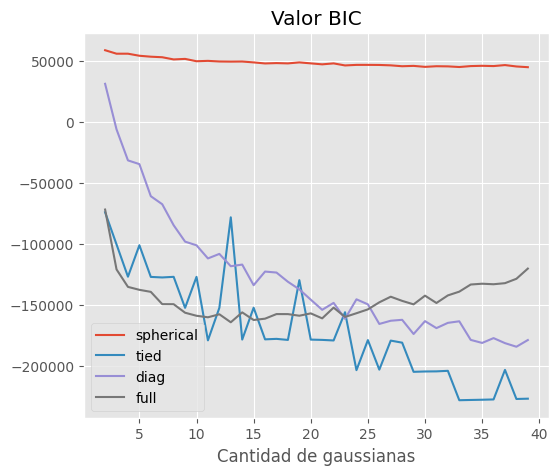

In [ ]:
from sklearn.mixture import GaussianMixture
fig,ax = plt.subplots(figsize = (6,5))
n_gauss = range(2,40)
var_types = ["spherical", "tied", "diag", "full"]
for covariance_type in var_types:
    valor_bic = []
    for i in n_gauss:
        modelo = GaussianMixture(n_components= i, covariance_type= covariance_type)
        modelo = modelo.fit(data_pro)
        valor_bic.append(modelo.bic(data_pro))

    ax.plot(n_gauss, valor_bic, label = covariance_type)

ax.set_title("Valor BIC")
ax.set_xlabel("Cantidad de gaussianas")
ax.legend()
plt.show()

* Podemos observar que el punto más bajo lo alcanza "tied" en una cantidad de gaussianas de $34$ más o menos

In [ ]:
gmm_final = GaussianMixture(n_components=34, covariance_type="tied")
gmm_final.fit(data_pro)

GaussianMixture(covariance_type='tied', n_components=34)

## 8. Evaluacion del modelo

* Se va a analizar cada uno de los modelos para ver cual es el mejor según el indice de silhouette

In [ ]:
label_kmean = kmeans_model_final.predict(data_pro)
label_h_clust = h_clust_final.fit_predict(data_pro)
label_gmm = gmm_final.predict(data_pro)
label_dbscan = dbscan_final.fit_predict(data_pro)

In [ ]:
# calculamos los silhouette
sil_kmeans = silhouette_score(data_pro,label_kmean)
sil_h_clust = silhouette_score(data_pro, label_h_clust)
sil_gmm = silhouette_score(data_pro, label_gmm)
sil_dbscan = silhouette_score(data_pro, label_dbscan)

print(f"El indice de Silhouette para: \n Kmeans = {round(sil_kmeans,2)} \n Jerarquico = {round(sil_h_clust,2)} \n DBSCAN = {round(sil_dbscan,2)} \n GMM = {round(sil_gmm,2)}")

El indice de Silhouette para: 
 Kmeans = 0.13 
 Jerarquico = 0.05 
 DBSCAN = 0.19 
 GMM = 0.11


* Podemos ver que el mayor silhoutte lo alcanza DBSCAN, pero tenemos que realizar una analisis más profundo para saber cuantos grupos hay y cuantos individuos aislados (puntos de ruido) hay

In [ ]:
np.unique(label_dbscan)

array([ -1,   0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,
        12,  13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,
        25,  26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,
        38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,
        51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,
        64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,
        77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,
        90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102,
       103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115,
       116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128,
       129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141,
       142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154,
       155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167,
       168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 17

* Con esto podemos ver que hay 333 grupos en los que se puede dividir los barcos de la naviera. Estos aun no incluyen los puntos de ruido que están representados por el -1
* Ahora encontremos los puntos de ruido

In [ ]:
data_pro["DBSCAN"] = label_dbscan
data_pro

,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,...,Engine_Type_Diesel,Engine_Type_Heavy Fuel Oil (HFO),Engine_Type_Steam Turbine,Maintenance_Status_Critical,Maintenance_Status_Fair,Maintenance_Status_Good,Weather_Condition_Calm,Weather_Condition_Moderate,Weather_Condition_Rough,DBSCAN
0,0.025219,0.518350,0.518533,0.966277,0.057553,0.966614,0.877777,0.854481,0.136018,0.385945,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,-1
1,0.716864,0.459279,0.312357,0.219996,0.065581,0.895450,0.361960,0.623798,0.285686,0.906517,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
2,0.737246,0.165608,0.552589,0.679530,0.865698,0.513139,0.039180,0.173291,0.431118,0.871380,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,-1
3,0.249169,0.235476,0.716076,0.473158,0.107941,0.566993,0.659079,0.869660,0.880651,0.083444,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1
4,0.574456,0.668767,0.345433,0.992633,0.955556,0.356328,0.765010,0.591406,0.908450,0.938453,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2122,0.950990,0.525326,0.050070,0.538327,0.718330,0.523370,0.811303,0.373858,0.434885,0.853635,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,219
2123,0.376418,0.464834,0.577805,0.757122,0.205984,0.783703,0.544452,0.171164,0.182992,0.579627,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,47
2124,0.106678,0.967826,0.097313,0.870945,0.137453,0.465401,0.717495,0.586004,0.643824,0.785504,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,159
2125,0.875916,0.611297,0.292008,0.162386,0.052959,0.030929,0.789251,0.038624,0.569005,0.403271,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,120


In [ ]:
data_pro.DBSCAN.value_counts()

DBSCAN
-1      242
 36      14
 60      12
 85      11
 81      11
       ... 
 280      3
 306      3
 273      3
 324      3
 331      3
Name: count, Length: 334, dtype: int64

* Con esto vemos que hay 242 individios aislados (ruido)
* Cada punto de ruido se tiene que tratar como un individuo aislado, un grupo aparte
* Por lo tanto, hay 575 grupos en la naviera

## Conclusiones
* Podemos **rechazar** directamente la hipotesis que se nos planteó, ya que el equipo técnico dice que los barcos pueden
dividirse en dos grupos definidos. Esto en realidad es rechazado por los 4 modelos que implementamos, ya que:
    * **kmeans:** Nos dice que hay 9 grupos definidos
    * **Agrupamiento jerarquico:** Nos dice que hay 3 grupos definidos
    * **DBSCAN:** Nos dice que hay 575 grupos definidos
    * **GMM:** Nos dice que hay 34 grupos definidos

Se ve que ninguno de los modelos apoya la hipotesis de que solo hay 2 grupos definidos

* En este ejercicio, el modelo más preciso es el de DBSCAN, lo que nos lleva a que si queremos mejorar el desempeño en las condiciones de trabajo de los empleados y la experiencia de los clientes de la naviera, necesitariamos dividir todo en 575 grupos. Esto para una empresa es poco práctico, ya que muchos de estos grupos son individios aislados. Si la empresa se empieza a enfocar en  individuos tan especificos, puede que la satisfacción incremente mucho, pero el tiempo y los recursos que se tendrían que destinar a estos serían demasiado.
* Con un analisis más profundo se podría ver si estos individuos aislados valen la pena de invertirles tanto tiempo y que generen una buena ganancia
* Pero por el momento, se escogería el modelo Kmeans el cual tiene el segundo indice de silhouette más alto, y aparte, este nos dice que hay 9 grupos definidos, una cantidad bastante óptima para la naviera que podría mejorar el desempeño y no gastar tantos recursos y tiempo